In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, ParameterGrid
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:
#montando drive e lendo df
drive.mount('/content/drive/')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Exam_Score_Prediction.csv')

df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Exluir feature student_id e normaliza exam_score para true e false, sendo true para notas igual ou acima de 60.

In [ ]:
df.drop(columns=['student_id'], inplace=True)

df['exam_score'] = df['exam_score'].apply(lambda x: 1 if x >= 60 else 0)

df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,0
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,0
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,1
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,0
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,0


verificando dados Faltantes e uniques das colunas

In [ ]:
print(df.isna().sum())
print("\n")

for col in df.columns:
    print("=" * 40)
    print(f"Coluna: {col}")
    print("Valores únicos:")
    print(df[col].unique())

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


Coluna: age
Valores únicos:
[17 23 22 20 18 21 24 19]
Coluna: gender
Valores únicos:
['male' 'other' 'female']
Coluna: course
Valores únicos:
['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']
Coluna: study_hours
Valores únicos:
[2.78 3.37 7.88 0.67 0.89 3.48 1.35 5.48 2.89 6.77 5.99 3.77 6.76 0.81
 4.65 4.84 1.97 0.4  4.28 4.11 5.23 1.7  1.44 7.82 0.91 7.91 5.76 5.03
 2.72 6.94 7.28 5.78 5.68 3.95 0.62 0.12 3.96 2.94 6.21 5.89 5.02 0.6
 1.89 0.75 7.83 1.02 7.74 0.9  6.9  4.6  6.65 5.07 6.15 5.85 2.08 7.48
 5.15 1.62 2.45 4.26 7.05 6.37 2.42 5.51 0.08 2.66 6.72 1.21 2.83 0.19
 1.17 3.92 7.2  0.68 6.96 5.35 2.32 1.55 6.31 5.8  2.44 0.43 5.04 0.72
 4.29 4.9  5.5  1.   3.68 3.71 6.68 3.75 3.25 0.99 5.56 4.96 5.74

Vendo maximo e minimo das colunas e a média das features numericas

In [ ]:
num_df = df.select_dtypes(include="number")

summary = pd.DataFrame({
    "min": num_df.min(),
    "mean": num_df.mean(),
    "max": num_df.max()
})

summary

,min,mean,max
age,17.00,20.473300,24.00
study_hours,0.08,4.007604,7.91
class_attendance,40.60,70.017365,99.40
sleep_hours,4.10,7.008560,9.90
exam_score,0.00,0.552350,1.00


Tratando variaveis ordinais com Label Enconding Manual e nominais com One-Hot Encoding

In [ ]:
ordinal_maps = {
    "sleep_quality": {"poor": 0, "average": 1, "good": 2},
    "facility_rating": {"low": 0, "medium": 1, "high": 2},
    "exam_difficulty": {"easy": 0, "moderate": 1, "hard": 2},
    "internet_access": {"no": 0, "yes": 1}
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

df = pd.get_dummies(
    df,
    columns=["gender", "course", "study_method"],
    drop_first=True
)

df.head()

,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score,gender_male,...,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,17,2.78,92.9,1,7.4,0,0,2,0,True,...,False,False,False,False,False,True,False,False,False,False
1,23,3.37,64.8,1,4.6,1,1,1,0,False,...,False,False,False,False,True,False,False,False,True,False
2,22,7.88,76.8,1,8.5,0,2,1,1,True,...,True,False,False,False,False,False,False,False,False,False
3,20,0.67,48.4,1,5.8,1,0,1,0,False,...,False,False,False,False,False,True,False,False,True,False
4,20,0.89,71.6,1,9.8,0,0,1,0,False,...,False,False,False,False,False,True,False,False,False,False


Separando em X e Y

In [ ]:
x = df.drop(columns=["exam_score"])
y = df["exam_score"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Criando Pipelines de treino e treinando

In [ ]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

param_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

gs_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring="f1", n_jobs=-1)
gs_lr.fit(x_train, y_train)


pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

param_svm = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1]
}

gs_svm = GridSearchCV(pipe_svm, param_svm, cv=5, scoring="f1", n_jobs=-1)
gs_svm.fit(x_train, y_train)


pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_knn = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"]
}

gs_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring="f1", n_jobs=-1)
gs_knn.fit(x_train, y_train)


pipe_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

gs_nb = GridSearchCV(pipe_nb, {}, cv=5, scoring="f1")
gs_nb.fit(x_train, y_train)


rf = RandomForestClassifier(random_state=42)

param_rf = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

gs_rf = GridSearchCV(rf, param_rf, cv=5, scoring="f1", n_jobs=-1)
gs_rf.fit(x_train, y_train)


xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

param_xgb = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1]
}

gs_xgb = GridSearchCV(xgb, param_xgb, cv=5, scoring="f1", n_jobs=-1)
gs_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 300], 'subsample': [0.8, 1]},
             scoring='f1')

Crainado função de Avaliação

In [ ]:
def evaluate(model):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [ ]:

best_params = {
    "Logistic Regression": gs_lr.best_params_,
    "SVM": gs_svm.best_params_,
    "k-NN": gs_knn.best_params_,
    "Naive Bayes": gs_nb.best_params_,
    "Random Forest": gs_rf.best_params_,
    "XGBoost": gs_xgb.best_params_
}

pd.DataFrame(best_params).T


,model__C,model__solver,model__gamma,model__n_neighbors,model__weights,model__alpha,model__hidden_layer_sizes,max_depth,min_samples_split,n_estimators,learning_rate,subsample
Logistic Regression,0.1,lbfgs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVM,1.0,NaN,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
k-NN,NaN,NaN,NaN,9,distance,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neural Network (MLP),NaN,NaN,NaN,NaN,NaN,0.001,"(64,)",NaN,NaN,NaN,NaN,NaN
Naive Bayes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,2.0,300.0,NaN,NaN
XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,300.0,0.05,0.8


Tabela de Comparação

In [ ]:
results = {
    "Logistic Regression": evaluate(gs_lr.best_estimator_),
    "SVM": evaluate(gs_svm.best_estimator_),
    "k-NN": evaluate(gs_knn.best_estimator_),
    "Naive Bayes": evaluate(gs_nb.best_estimator_),
    "Random Forest": evaluate(gs_rf.best_estimator_),
    "XGBoost": evaluate(gs_xgb.best_estimator_)
}

pd.DataFrame(results).T.sort_values("F1", ascending=False)


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.84225,0.857661,0.856496,0.857078,0.924740
SVM,0.84000,0.857078,0.852422,0.854744,0.923786
XGBoost,0.83825,0.858257,0.846990,0.852586,0.922283
Random Forest,0.83025,0.845841,0.846990,0.846415,0.913064
Naive Bayes,0.82050,0.838402,0.836125,0.837262,0.908577
k-NN,0.78775,0.798770,0.822997,0.810702,0.862651


In [ ]:
feature_names = x_train.columns

lr_best = gs_lr.best_estimator_

coef_lr = lr_best.named_steps["model"].coef_[0]

importance_lr = pd.Series(
    np.abs(coef_lr),
    index=feature_names
).sort_values(ascending=False)

importance_lr.head(10)

,0
study_hours,2.415945
class_attendance,1.061151
study_method_self-study,0.700632
sleep_quality,0.690038
study_method_online videos,0.642166
facility_rating,0.585083
study_method_group study,0.534642
sleep_hours,0.453365
study_method_mixed,0.336519
gender_male,0.040490


In [ ]:
rf_best = gs_rf.best_estimator_

importance_rf = pd.Series(
    rf_best.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance_rf.head(10)

,0
study_hours,0.471265
class_attendance,0.150498
sleep_hours,0.091907
age,0.050953
sleep_quality,0.036276
facility_rating,0.031975
exam_difficulty,0.026291
gender_male,0.014153
gender_other,0.014115
study_method_self-study,0.011982


In [ ]:
xgb_best = gs_xgb.best_estimator_

importance_xgb = pd.Series(
    xgb_best.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance_xgb.head(10)

,0
study_hours,0.329234
sleep_quality,0.103039
class_attendance,0.093014
facility_rating,0.091745
study_method_group study,0.059979
study_method_online videos,0.056747
study_method_self-study,0.055891
sleep_hours,0.043143
study_method_mixed,0.028703
course_bca,0.018304


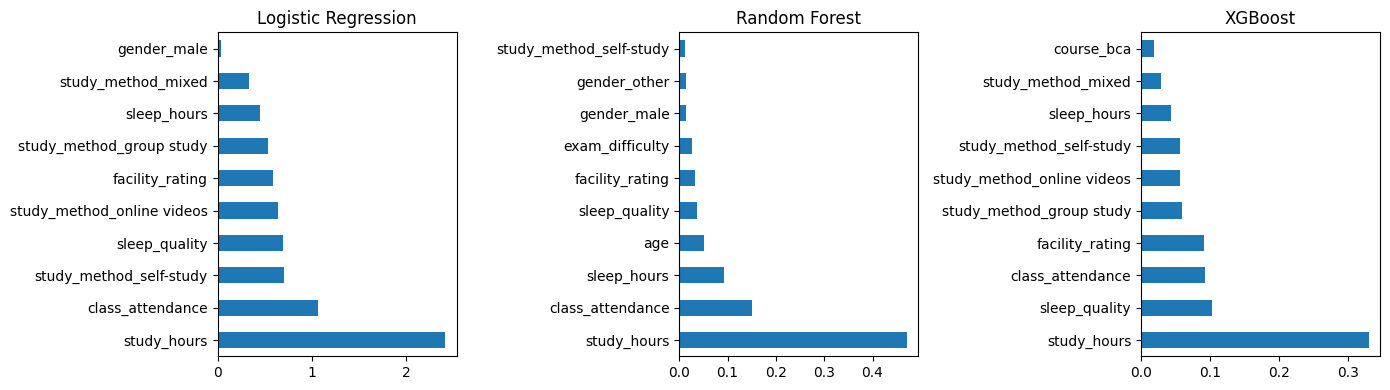

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
importance_lr.head(10).plot(kind="barh")
plt.title("Logistic Regression")

plt.subplot(1,3,2)
importance_rf.head(10).plot(kind="barh")
plt.title("Random Forest")

plt.subplot(1,3,3)
importance_xgb.head(10).plot(kind="barh")
plt.title("XGBoost")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test, label):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

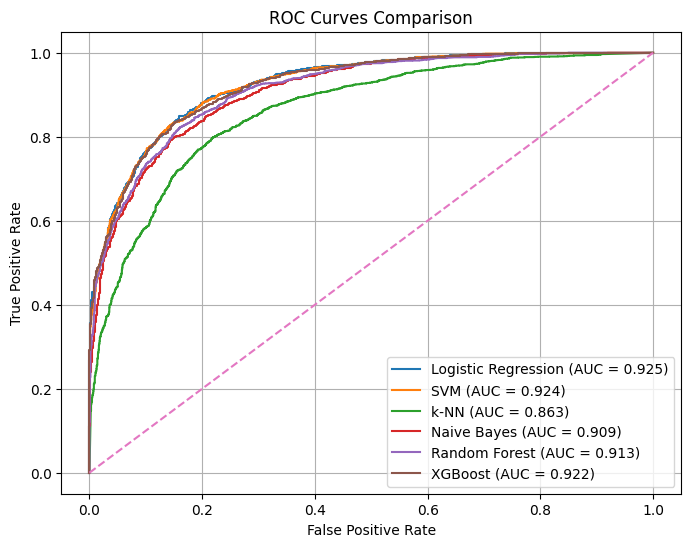

In [ ]:
plt.figure(figsize=(8,6))

plot_roc(gs_lr.best_estimator_, x_test, y_test, "Logistic Regression")
plot_roc(gs_svm.best_estimator_, x_test, y_test, "SVM")
plot_roc(gs_knn.best_estimator_, x_test, y_test, "k-NN")
plot_roc(gs_nb.best_estimator_, x_test, y_test, "Naive Bayes")
plot_roc(gs_rf.best_estimator_, x_test, y_test, "Random Forest")
plot_roc(gs_xgb.best_estimator_, x_test, y_test, "XGBoost")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid()
plt.show()
